# The Solow model

**Table of contents**<a id='toc0_'></a>    
- 1. [The Solow model](#toc1_)    
- 2. [Setup](#toc2_)    
- 3. [The model as a class](#toc3_)    
- 4. [The steady state](#toc4_)    
  - 4.1. [By hand](#toc4_1_)    
  - 4.2. [With a root-finder](#toc4_2_)    
  - 4.3. [Testing the code](#toc4_3_)    
- 5. [The steady-state diagram](#toc5_)    
- 6. [Convergence](#toc6_)    
  - 6.1. [The stairway diagram](#toc6_1_)    
  - 6.2. [Time paths](#toc6_2_)    
  - 6.3. [How fast is the convergence?](#toc6_3_)    
- 7. [The savings rate](#toc7_)    
  - 7.1. [Comparing steady states](#toc7_1_)    
  - 7.2. [The transition](#toc7_2_)    
  - 7.3. [Which savings rate is best?](#toc7_3_)    
- 8. [A stochastic savings rate](#toc8_)    
  - 8.1. [A single economy](#toc8_1_)    
  - 8.2. [Many economies](#toc8_2_)    
  - 8.3. [Vectorizing over economies](#toc8_3_)    
- 9. [Summary](#toc9_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In this lecture we take a small economic model - the **Solow model** - all the way from equations on paper to figures on the screen.

**The focus is programming, not growth theory.** The model is only used because it is small enough to fit on one page, but rich enough that we get to practice everything from the previous lectures:

1. Write the model as a **class** (lecture 3).
2. Solve it **analytically** and **numerically**, and check that the two agree (lecture 5).
3. **Simulate** it forward in time with a loop - and **test** that the code does what we think it does.
4. Make **nice figures** of the results (lecture 4).
5. Add **random numbers** and simulate many economies at once (lecture 6).

You do *not* need to know the Solow model in advance. Everything you need is on the next page.

## 1. <a id='toc1_'></a>[The Solow model](#toc0_)

The model describes how the **capital stock** of an economy evolves over time. Everything is measured **per worker**:

* $k_t$: capital per worker (machines, buildings, roads, ...)
* $y_t$: output per worker (GDP)
* $i_t$: investment per worker
* $c_t$: consumption per worker

**Production.** Output is produced with capital,

$$ y_t = f(k_t) = k_t^{\alpha}, \qquad 0 < \alpha < 1 $$

The function is increasing and *concave*: more capital gives more output, but each extra machine adds less than the previous one.

**Saving.** A constant share $s$ of output is saved and invested, the rest is consumed,

$$ i_t = s\,y_t, \qquad c_t = (1-s)\,y_t $$

**Accumulation.** Next period's capital is the investment made today plus what is left of today's capital after a share $\delta$ of it has worn down,

$$ k_{t+1} = i_t + (1-\delta)k_t = s f(k_t) + (1-\delta)k_t $$

This single equation *is* the model: given a starting point $k_0$, it determines the whole future of the economy.

**Steady state.** The economy is in **steady state** when capital stops changing, $k_{t+1} = k_t = k^{\ast}$. Inserting this in the equation above gives

$$ s f(k^{\ast}) = \delta k^{\ast} $$

i.e. new investment exactly replaces the capital that wears down. With $f(k) = k^{\alpha}$ we can isolate $k^{\ast}$ by hand,

$$ k^{\ast} = \left(\frac{s}{\delta}\right)^{\frac{1}{1-\alpha}}, \qquad y^{\ast} = (k^{\ast})^{\alpha}, \qquad c^{\ast} = (1-s)\,y^{\ast} $$

Having a solution we can compute by hand is *very* useful: we can use it to test that our code is correct.

## 2. <a id='toc2_'></a>[Setup](#toc0_)

We import the packages we need and set the plotting options used in all lectures.

In [1]:
from types import SimpleNamespace
from scipy import optimize
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'-'})
plt.rcParams.update({'font.size':14})

# the default colors of matplotlib (nice to have when we want to control colors by hand)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

## 3. <a id='toc3_'></a>[The model as a class](#toc0_)

We write the model as a **class**, following exactly the pattern from lecture 3:

* the **parameters** ($\alpha$, $s$, $\delta$) and the simulation settings ($k_0$, $T$) are **attributes** set in `__init__`
* the **equations** of the model ($f$, the law of motion, the steady state) are **methods**
* the **simulator** is a method that stores its results in `self.sim`

**Why bother with a class?** Because everything then belongs together in one object. We can create several economies with different parameters, and each of them carries its own parameters, its own equations and its own results around:

```python
model_A = SolowModel(s=0.20)
model_B = SolowModel(s=0.30)
```

**Where is the code?** The class is a bit too long for a notebook cell, so it lives in its own file, **[solow.py](solow.py)**. That is how you should write your own models too: the model in a `.py` file, the *use* of it in the notebook. Open the file and read along - the methods are listed below.

In [2]:
from solow import SolowModel # the model class, see solow.py

The class has one attribute per parameter and one method per equation:

| | |
| --- | --- |
| `f(k)` | output per worker, $f(k)=k^{\alpha}$ |
| `k_next(k,s)` | the law of motion, $k_{t+1}=sf(k_t)+(1-\delta)k_t$ |
| `steady_state()` | the analytical steady state, returns $(k^{\ast},y^{\ast},c^{\ast})$ |
| `solve_steady_state()` | the same, found with a root-finder |
| `simulate(s,k0,T)` | simulate forward in time, results in `self.sim` |

**Note on `simulate`:** the savings rate is allowed to be either a *single number* (constant over time) or an *array* with one value per period. That small piece of flexibility is what makes the same method usable for all the experiments below - also the stochastic one in section 8.

**Note on the default parameters:** they are chosen so the figures below are easy to read. A period is *not* meant to be one year - think of it as a handful of years, so that a third of the capital stock wears down within a period.

We create an instance of the model and print it (this calls `__str__`):

In [3]:
model = SolowModel()
print(model)

Solow model with:
  alpha = 0.33 (capital share)
  s     = 0.20 (savings rate)
  delta = 0.30 (depreciation rate)
  k0    = 0.10 (initial capital per worker)
  T     = 50 (number of periods)


Attributes are read and changed with **.-notation**, and a new model with other parameters is created by passing keyword arguments:

In [4]:
print(f'the savings rate is {model.s:.2f}')

model_high_s = SolowModel(s=0.30) # only s is changed, everything else is the default
print(f'the savings rate is {model_high_s.s:.2f} in the alternative model')

the savings rate is 0.20
the savings rate is 0.30 in the alternative model


## 4. <a id='toc4_'></a>[The steady state](#toc0_)

### 4.1. <a id='toc4_1_'></a>[By hand](#toc0_)

The method `steady_state()` implements the formulas we derived by hand:

In [5]:
k_ss,y_ss,c_ss = model.steady_state()

print(f'k* = {k_ss:.4f}')
print(f'y* = {y_ss:.4f}')
print(f'c* = {c_ss:.4f}')

k* = 0.5443
y* = 0.8165
c* = 0.6532


**Task:** Create a model where capital wears down twice as fast, $\delta = 0.60$, and print its steady state. Should $k^{\ast}$ be higher or lower than in the baseline?

In [6]:
# write your code here

In [7]:
# answer
model_fast = SolowModel(delta=0.60) # only delta is changed
k_fast,y_fast,c_fast = model_fast.steady_state()

print(f'k* = {k_fast:.4f} with delta = {model_fast.delta:.2f}')
print(f'k* = {k_ss:.4f} with delta = {model.delta:.2f} (baseline)')

k* = 0.1925 with delta = 0.60
k* = 0.5443 with delta = 0.30 (baseline)


### 4.2. <a id='toc4_2_'></a>[With a root-finder](#toc0_)

In almost all interesting models there is **no formula** for the steady state. Then we solve the equation

$$ \underbrace{s f(k) + (1-\delta)k - k}_{\text{zero in the steady state}} = 0 $$

numerically with a root-finder (lecture 5). This is what `solve_steady_state()` does with `optimize.root_scalar`.

In [8]:
k_ss_num = model.solve_steady_state()

print(f'k* (by hand)   = {k_ss:.8f}')
print(f'k* (root-finder) = {k_ss_num:.8f}')
print(f'the two agree: {np.isclose(k_ss,k_ss_num)}')

k* (by hand)   = 0.54433105
k* (root-finder) = 0.54433105
the two agree: True


**Good habit:** when you *can* solve a problem by hand, always use it to test your numerical code. When you later change the model to a case you cannot solve by hand, you will then trust the code.

### 4.3. <a id='toc4_3_'></a>[Testing the code](#toc0_)

Before we start *using* the model we should convince ourselves that it does what we think it does. A cheap and surprisingly effective way is a handful of **`assert` statements**: an `assert` does nothing when the condition is `True`, and stops with an error when it is `False`.

The art is to find cases where you already know the answer:

1. an economy that **starts** in the steady state must **stay** there
2. if nothing is saved ($s=0$), capital just decays: $k_t = (1-\delta)^t k_0$
3. everything produced must be either consumed or invested: $y_t = c_t + i_t$

In [9]:
# test 1: the steady state is a resting point
sim = SolowModel(k0=k_ss,T=20).simulate()
assert np.allclose(sim.k,k_ss), 'the economy does not stay in the steady state'

# test 2: with s = 0 capital decays at the rate delta
model_test = SolowModel(k0=1.0,T=20)
sim = model_test.simulate(s=0.0)
k_decay = model_test.k0*(1-model_test.delta)**np.arange(model_test.T)
assert np.allclose(sim.k,k_decay), 'capital does not decay correctly'

# test 3: the accounting adds up
sim = model.simulate()
assert np.allclose(sim.y,sim.c+sim.i), 'output is not consumption plus investment'

print('all tests passed')

all tests passed


**No news is good news:** if the cell runs without complaining, all three tests passed.

Re-run the tests every time you change the class. A broken test points straight at the bug - a wrong figure does not.

**Task:** Add a test of the extreme case $\delta = 1$, where *all* capital wears down within one period, so that $k_{t+1} = s f(k_t)$.

In [10]:
# write your code here

In [11]:
# answer
model_test = SolowModel(delta=1.0,k0=0.50,T=20)
sim = model_test.simulate()

# all periods except the first, compared to s*f(k) in all periods except the last
assert np.allclose(sim.k[1:],model_test.s*model_test.f(sim.k[:-1])), 'wrong when delta = 1'

print('test passed')

test passed


## 5. <a id='toc5_'></a>[The steady-state diagram](#toc0_)

The classic figure of the model: output $f(k)$, investment $sf(k)$ and depreciation $\delta k$ as functions of capital.

Where the investment curve crosses the depreciation line, capital is constant - that is the steady state $k^{\ast}$. The gap between output and investment is consumption.

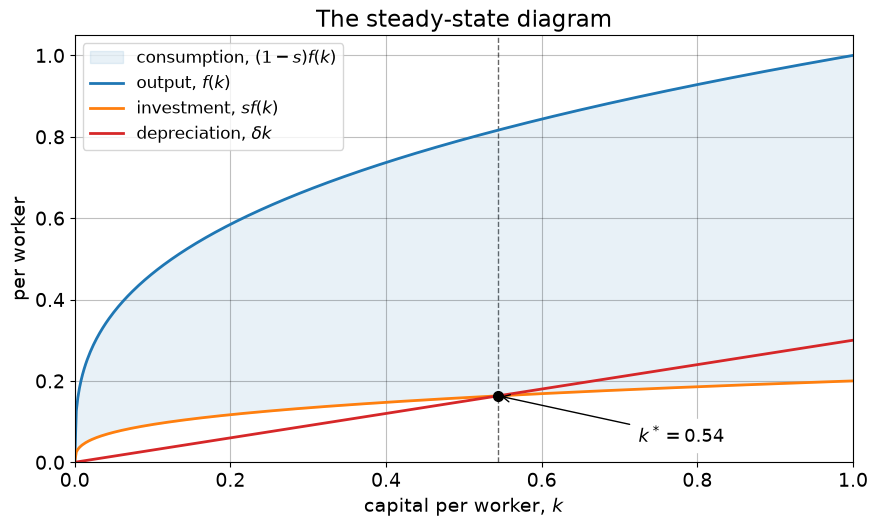

In [12]:
# a. grid of capital values
k_max = 1.0
k_grid = np.linspace(0,k_max,500)

# b. the curves
y_grid = model.f(k_grid) # output
i_grid = model.s*y_grid # investment
d_grid = model.delta*k_grid # depreciation

# c. figure
fig = plt.figure(figsize=(9,5.5))
ax = fig.add_subplot(1,1,1)

ax.fill_between(k_grid,i_grid,y_grid,color=colors[0],alpha=0.10,label=r'consumption, $(1-s)f(k)$')
ax.plot(k_grid,y_grid,lw=2,color=colors[0],label=r'output, $f(k)$')
ax.plot(k_grid,i_grid,lw=2,color=colors[1],label=r'investment, $sf(k)$')
ax.plot(k_grid,d_grid,lw=2,color=colors[3],label=r'depreciation, $\delta k$')

# d. mark the steady state
ax.plot(k_ss,model.delta*k_ss,'o',color='black',ms=7,zorder=3)
ax.axvline(k_ss,ls='--',lw=1,color='black',alpha=0.6,zorder=0)
ax.annotate(f'$k^*={k_ss:.2f}$',xy=(k_ss,model.delta*k_ss),xytext=(k_ss+0.18,0.05),
            arrowprops=dict(arrowstyle='->'),fontsize=13,backgroundcolor='white')

# e. labels
ax.set_title('The steady-state diagram')
ax.set_xlabel('capital per worker, $k$')
ax.set_ylabel('per worker')
ax.set_xlim(0,k_max)
ax.set_ylim(0,1.05*y_grid.max())
ax.legend(loc='upper left',fontsize=12)

fig.tight_layout()

**Reading the figure.** To the *left* of $k^{\ast}$ investment is above depreciation, so capital grows. To the *right* it is the other way around, so capital falls. The economy is pulled towards $k^{\ast}$ from both sides.

## 6. <a id='toc6_'></a>[Convergence](#toc0_)

### 6.1. <a id='toc6_1_'></a>[The stairway diagram](#toc0_)

The law of motion $k_{t+1} = sf(k_t) + (1-\delta)k_t$ is a function that maps **today's** capital into **tomorrow's** capital. So we can draw it with $k_t$ on the x-axis and $k_{t+1}$ on the y-axis, together with the **45-degree line** where $k_{t+1} = k_t$.

The two curves cross exactly in the steady state. And from a starting point $k_0$ we can now *read off* the whole path with a simple recipe:

1. go **up** from $k_0$ to the curve - the height is $k_1$
2. go **across** to the 45-degree line - this moves $k_1$ down to the x-axis
3. repeat

The result looks like a **stairway** climbing towards the steady state.

First we simulate two economies: one starting far below and one starting far above the steady state.

In [13]:
model_below = SolowModel(k0=0.05,T=40)
model_above = SolowModel(k0=0.95,T=40)

sim_below = model_below.simulate()
sim_above = model_above.simulate()

print(f'from below: k0 = {sim_below.k[0]:.2f} -> last period: k = {sim_below.k[-1]:.4f}')
print(f'from above: k0 = {sim_above.k[0]:.2f} -> last period: k = {sim_above.k[-1]:.4f}')
print(f'the steady state is k* = {k_ss:.4f}')

from below: k0 = 0.05 -> last period: k = 0.5442
from above: k0 = 0.95 -> last period: k = 0.5444
the steady state is k* = 0.5443


Then we write a small helper function that turns a simulated path into the **coordinates of the stairway**, and use it in a figure with one panel per starting point.

In [14]:
def stairway(k,n_steps):
    """ coordinates of the stairway for a simulated path of capital

    Args:

        k (ndarray): simulated capital per worker
        n_steps (int): number of steps to draw

    Returns:

        (list,list): x- and y-coordinates of the stairway

    """

    x = [k[0]] # start on the 45-degree line in (k0,k0)
    y = [k[0]]

    for t in range(n_steps):
        x += [k[t],k[t+1]] # first up to the curve, then across to the 45-degree line
        y += [k[t+1],k[t+1]]

    return x,y

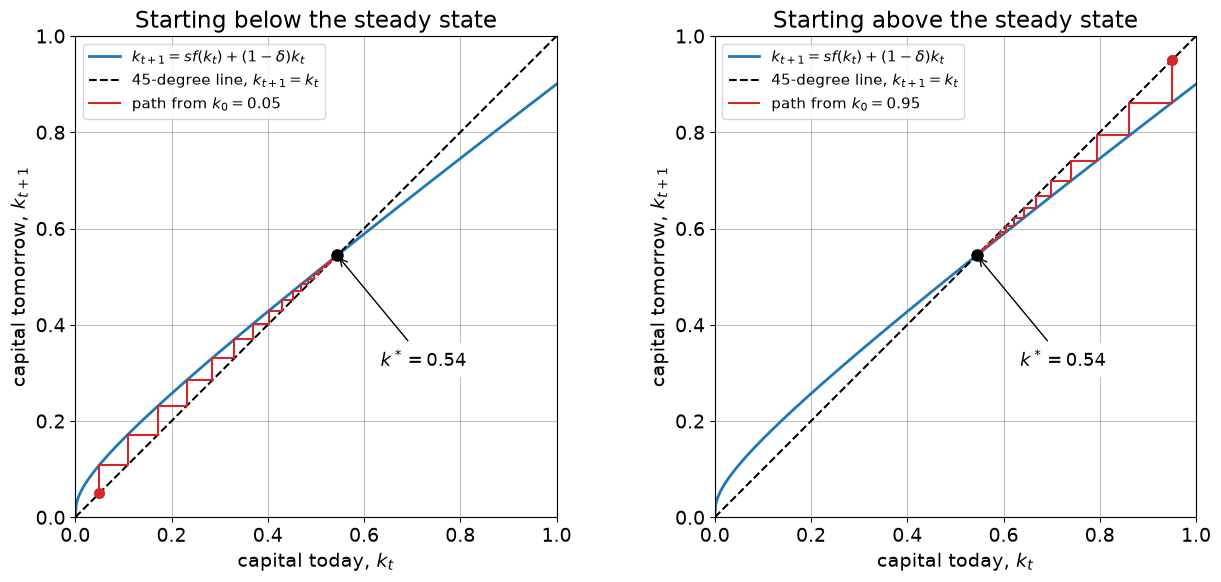

In [15]:
# a. the law of motion on the same grid of capital values as above
g_grid = model.k_next(k_grid)

# b. figure with one panel per starting point
fig = plt.figure(figsize=(13,6))

for i,(sim,txt) in enumerate(zip([sim_below,sim_above],['below','above'])):

    ax = fig.add_subplot(1,2,1+i)

    # i. the law of motion and the 45-degree line
    ax.plot(k_grid,g_grid,lw=2,color=colors[0],label=r'$k_{t+1} = sf(k_t)+(1-\delta)k_t$')
    ax.plot(k_grid,k_grid,lw=1.5,ls='--',color='black',label=r'45-degree line, $k_{t+1}=k_t$')

    # ii. the stairway
    x,y = stairway(sim.k,n_steps=20)
    ax.plot(x,y,lw=1.5,color=colors[3],label=f'path from $k_0={sim.k[0]:.2f}$')
    ax.plot(sim.k[0],sim.k[0],'o',ms=7,color=colors[3],zorder=3)

    # iii. the steady state
    ax.plot(k_ss,k_ss,'o',ms=8,color='black',zorder=3)
    ax.annotate(f'$k^*={k_ss:.2f}$',xy=(k_ss,k_ss),xytext=(k_ss+0.09,k_ss-0.23),
                arrowprops=dict(arrowstyle='->'),fontsize=13,backgroundcolor='white')

    # iv. labels
    ax.set_title(f'Starting {txt} the steady state')
    ax.set_xlabel('capital today, $k_t$')
    ax.set_ylabel('capital tomorrow, $k_{t+1}$')
    ax.set_xlim(0,k_max)
    ax.set_ylim(0,k_max)
    ax.set_aspect('equal')
    ax.legend(loc='upper left',fontsize=11)

fig.tight_layout()

**Note the steps get shorter and shorter** as we approach $k^{\ast}$: the economy converges fast in the beginning and then more and more slowly. That is exactly what we see in the time paths below.

### 6.2. <a id='toc6_2_'></a>[Time paths](#toc0_)

The same two simulations, now plotted against time.

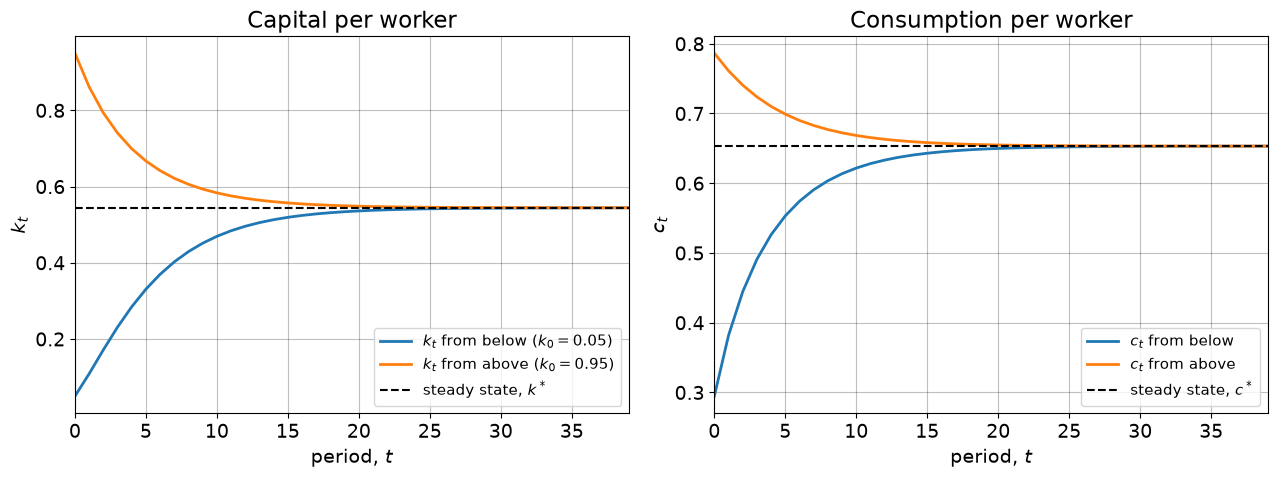

In [16]:
fig = plt.figure(figsize=(13,5))

ax_k = fig.add_subplot(1,2,1)
ax_c = fig.add_subplot(1,2,2)

for sim,txt in zip([sim_below,sim_above],['from below','from above']):
    ax_k.plot(sim.k,lw=2,label=f'$k_t$ {txt} ($k_0={sim.k[0]:.2f}$)')
    ax_c.plot(sim.c,lw=2,label=f'$c_t$ {txt}')

ax_k.axhline(k_ss,ls='--',lw=1.5,color='black',label='steady state, $k^*$')
ax_c.axhline(c_ss,ls='--',lw=1.5,color='black',label='steady state, $c^*$')

ax_k.set_title('Capital per worker')
ax_k.set_ylabel('$k_t$')
ax_c.set_title('Consumption per worker')
ax_c.set_ylabel('$c_t$')

for ax in [ax_k,ax_c]:
    ax.set_xlabel('period, $t$')
    ax.set_xlim(0,sim_below.k.size-1)
    ax.legend(loc='lower right',fontsize=11)

fig.tight_layout()

### 6.3. <a id='toc6_3_'></a>[How fast is the convergence?](#toc0_)

The stairway showed that the steps get smaller and smaller close to the steady state. A simple measure of the speed is the **half-life**: how many periods does it take to close *half* the distance to the steady state? We simulate and **search**.

In [17]:
def half_life(model):
    """ the number of periods it takes to close half the distance to the steady state

    Args:

        model (SolowModel): the model to simulate

    Returns:

        (int): the first period where the distance is less than half the initial distance

    """

    # a. simulate
    k_ss,y_ss,c_ss = model.steady_state()
    sim = model.simulate()

    # b. distance to the steady state in each period
    distance = np.abs(sim.k-k_ss)

    # c. search for the first period where the distance is halved
    for t in range(model.T):
        if distance[t] < 0.5*distance[0]:
            return t

    return np.nan # not reached within T periods

In [18]:
model_hl = SolowModel(T=200)
model_hl.k0 = 0.90*k_ss # start close to the steady state

print(f'the half-life is {half_life(model_hl)} periods')

the half-life is 4 periods


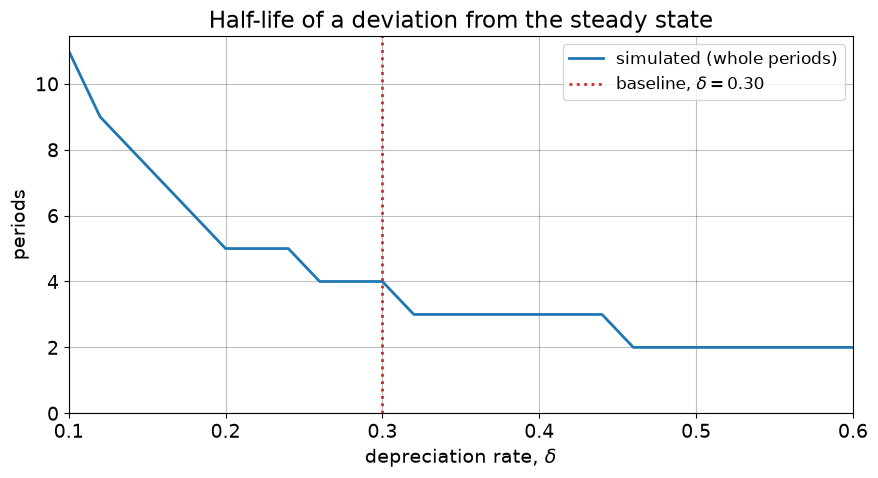

In [19]:
# a. run the search for a grid of depreciation rates
delta_grid = np.linspace(0.10,0.60,26)

half_lives = np.empty(delta_grid.size)
for i,delta in enumerate(delta_grid):
    model_i = SolowModel(delta=delta,T=200)
    model_i.k0 = 0.90*model_i.steady_state()[0]
    half_lives[i] = half_life(model_i)

# b. figure
fig = plt.figure(figsize=(9,5))
ax = fig.add_subplot(1,1,1)

ax.plot(delta_grid,half_lives,lw=2,color=colors[0],label='simulated (whole periods)')
ax.axvline(model.delta,ls=':',lw=2,color=colors[3],label=f'baseline, $\\delta={model.delta:.2f}$')

ax.set_title('Half-life of a deviation from the steady state')
ax.set_xlabel(r'depreciation rate, $\delta$')
ax.set_ylabel('periods')
ax.set_xlim(delta_grid[0],delta_grid[-1])
ax.set_ylim(0,None)
ax.legend(loc='upper right',fontsize=12)

fig.tight_layout()

**Task:** Does the half-life depend on the savings rate? Check it in code: print the steady state and the half-life for $s = 0.05, 0.20, 0.50$ and $0.80$.

In [20]:
# write your code here

In [21]:
# answer
for s in [0.05,0.20,0.50,0.80]:

    model_s = SolowModel(s=s,T=200)
    k_ss_s = model_s.steady_state()[0]
    model_s.k0 = 0.90*k_ss_s # always start 10 percent below the steady state

    print(f's = {s:.2f}: k* = {k_ss_s:.4f}, half-life = {half_life(model_s)} periods')

s = 0.05: k* = 0.0680, half-life = 4 periods
s = 0.20: k* = 0.5443, half-life = 4 periods
s = 0.50: k* = 2.1517, half-life = 4 periods
s = 0.80: k* = 4.3546, half-life = 4 periods


The steady state moves from $0.07$ to $4.35$, but the half-life is the same in all four economies. **Where** you are heading and **how fast** you get there are two different questions.

## 7. <a id='toc7_'></a>[The savings rate](#toc0_)

### 7.1. <a id='toc7_1_'></a>[Comparing steady states](#toc0_)

**Comparative statics** means: change a parameter and compare the steady states. Because we wrote the model as a class we can simply create one model per savings rate in a **list comprehension**.

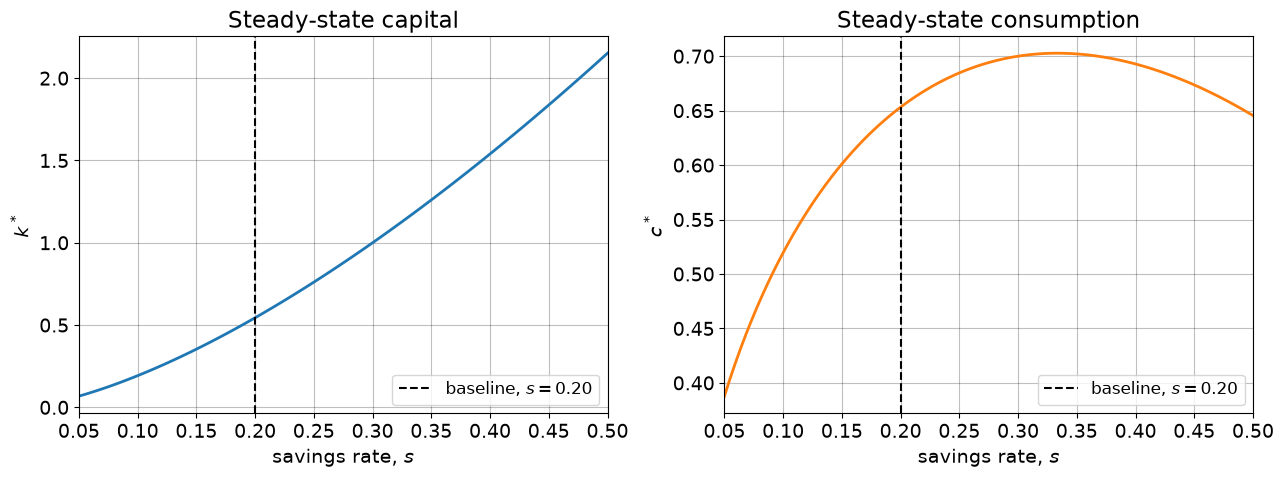

In [22]:
# a. one model per savings rate
s_grid = np.linspace(0.05,0.50,100)
k_ss_grid = np.array([SolowModel(s=s).steady_state()[0] for s in s_grid])
c_ss_grid = np.array([SolowModel(s=s).steady_state()[2] for s in s_grid])

# b. figure
fig = plt.figure(figsize=(13,5))

ax_k = fig.add_subplot(1,2,1)
ax_k.plot(s_grid,k_ss_grid,lw=2,color=colors[0])
ax_k.set_title('Steady-state capital')
ax_k.set_ylabel('$k^*$')

ax_c = fig.add_subplot(1,2,2)
ax_c.plot(s_grid,c_ss_grid,lw=2,color=colors[1])
ax_c.set_title('Steady-state consumption')
ax_c.set_ylabel('$c^*$')

for ax in [ax_k,ax_c]:
    ax.axvline(model.s,ls='--',lw=1.5,color='black',label=f'baseline, $s={model.s:.2f}$')
    ax.set_xlabel('savings rate, $s$')
    ax.set_xlim(s_grid[0],s_grid[-1])
    ax.legend(loc='lower right',fontsize=12)

fig.tight_layout()

More saving always gives more capital, but consumption is a *hump*: saving everything leaves nothing to consume. We come back to the top of that hump in section 7.3.

### 7.2. <a id='toc7_2_'></a>[The transition](#toc0_)

Comparative statics only compares the end points. To see how the economy *moves* from the old to the new steady state we simulate with a **time-varying** savings rate: an array where the first $t_{\text{shock}}$ elements are the old savings rate and the rest are the new one.

In [23]:
# a. the path of the savings rate
T = 60
t_shock = 10
s_new = 0.30

s_path = np.full(T,model.s)
s_path[t_shock:] = s_new

# b. simulate, starting from the old steady state
model_shock = SolowModel(k0=k_ss,T=T)
sim_shock = model_shock.simulate(s=s_path)

# c. the new steady state
k_ss_new,y_ss_new,c_ss_new = SolowModel(s=s_new).steady_state()

print(f'k*: {k_ss:.3f} -> {k_ss_new:.3f}')
print(f'c*: {c_ss:.3f} -> {c_ss_new:.3f}')

k*: 0.544 -> 1.000
c*: 0.653 -> 0.700


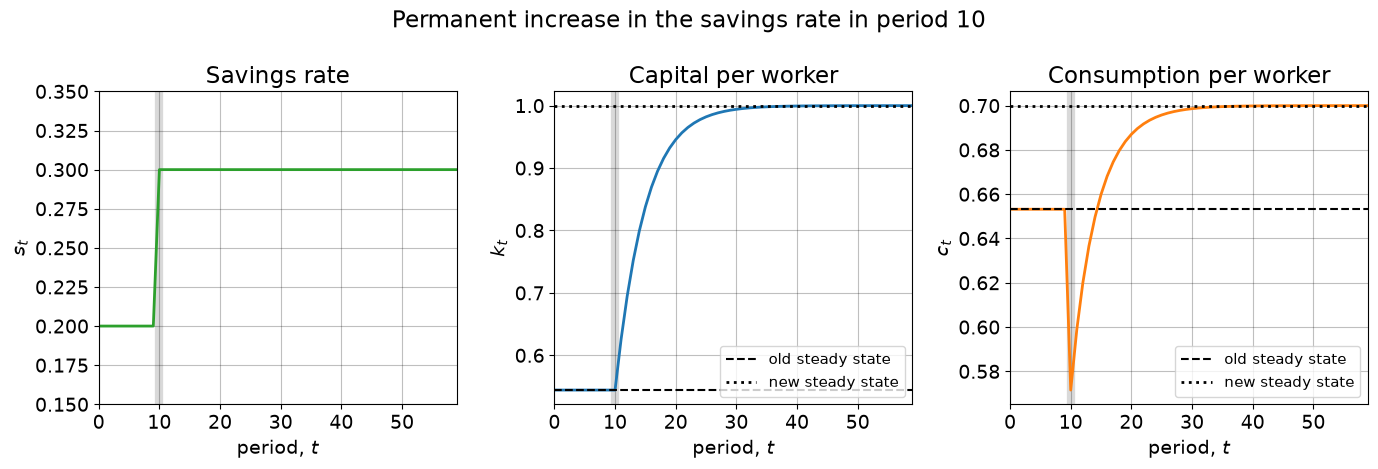

In [24]:
fig = plt.figure(figsize=(14,4.8))

# a. the savings rate
ax = fig.add_subplot(1,3,1)
ax.plot(sim_shock.s,lw=2,color=colors[2])
ax.set_title('Savings rate')
ax.set_ylabel('$s_t$')
ax.set_ylim(0.15,0.35)

# b. capital
ax = fig.add_subplot(1,3,2)
ax.plot(sim_shock.k,lw=2,color=colors[0])
ax.axhline(k_ss,ls='--',lw=1.5,color='black',label='old steady state')
ax.axhline(k_ss_new,ls=':',lw=2,color='black',label='new steady state')
ax.set_title('Capital per worker')
ax.set_ylabel('$k_t$')
ax.legend(loc='lower right',fontsize=11)

# c. consumption
ax = fig.add_subplot(1,3,3)
ax.plot(sim_shock.c,lw=2,color=colors[1])
ax.axhline(c_ss,ls='--',lw=1.5,color='black',label='old steady state')
ax.axhline(c_ss_new,ls=':',lw=2,color='black',label='new steady state')
ax.set_title('Consumption per worker')
ax.set_ylabel('$c_t$')
ax.legend(loc='lower right',fontsize=11)

for ax in fig.axes:
    ax.axvline(t_shock,lw=6,color='black',alpha=0.15,zorder=0)
    ax.set_xlabel('period, $t$')
    ax.set_xlim(0,T-1)

fig.suptitle(f'Permanent increase in the savings rate in period {t_shock}')
fig.tight_layout()

Consumption **drops on impact** (more of output is saved) and then grows back as the larger capital stock is built up.

### 7.3. <a id='toc7_3_'></a>[Which savings rate is best?](#toc0_)

The consumption curve in section 7.1 has a clear top. Which savings rate is at the top?

We have the function - we just need to find its maximum. `optimize.minimize_scalar` (lecture 5) *minimizes*, so we hand it **minus** steady-state consumption. Note how little code this takes: the model class already does all the work.

In [25]:
def minus_c_ss(s):
    """ minus steady-state consumption for a given savings rate """

    model_s = SolowModel(s=s) # a new model with this savings rate
    k,y,c = model_s.steady_state()

    return -c # minus, because we are using a minimizer

In [26]:
result = optimize.minimize_scalar(minus_c_ss,bounds=(0.01,0.99),method='bounded')

s_best = result.x
c_best = -result.fun

print(f'the best savings rate is s = {s_best:.4f}')
print(f'it gives steady-state consumption c* = {c_best:.4f} (baseline: {c_ss:.4f})')

the best savings rate is s = 0.3333
it gives steady-state consumption c* = 0.7027 (baseline: 0.6532)


**Does it look right?** It can be shown with pen and paper that the answer is exactly $s = \alpha$ - the capital share. So, as in section 4.2, we have an analytical answer to test the numerical one against.

In [27]:
print(f'the numerical answer is s = {s_best:.6f}')
print(f'the capital share is alpha = {model.alpha:.6f}')
print(f'the two agree: {np.isclose(s_best,model.alpha,atol=1e-4)}')

the numerical answer is s = 0.333334
the capital share is alpha = 0.333333
the two agree: True


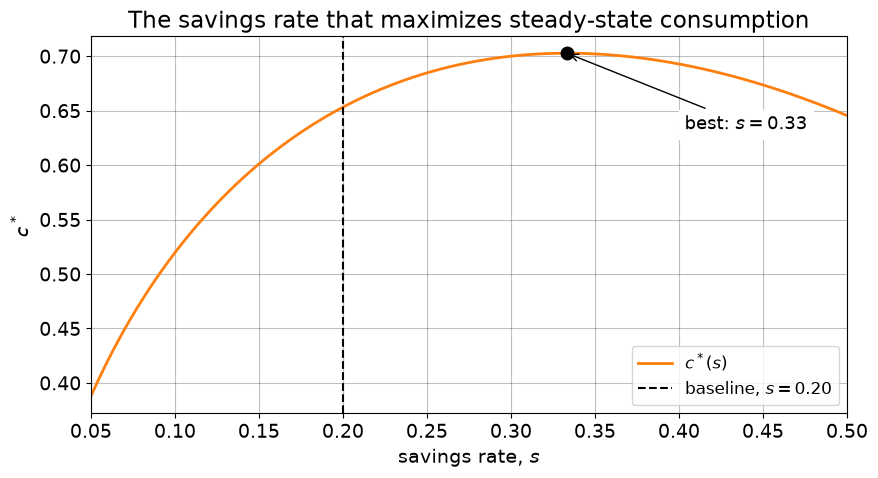

In [28]:
fig = plt.figure(figsize=(9,5))
ax = fig.add_subplot(1,1,1)

ax.plot(s_grid,c_ss_grid,lw=2,color=colors[1],label='$c^*(s)$')
ax.plot(s_best,c_best,'o',ms=9,color='black',zorder=3)
ax.axvline(model.s,ls='--',lw=1.5,color='black',label=f'baseline, $s={model.s:.2f}$')

ax.annotate(f'best: $s={s_best:.2f}$',xy=(s_best,c_best),xytext=(s_best+0.07,c_best-0.07),
            arrowprops=dict(arrowstyle='->'),fontsize=13,backgroundcolor='white')

ax.set_title('The savings rate that maximizes steady-state consumption')
ax.set_xlabel('savings rate, $s$')
ax.set_ylabel('$c^*$')
ax.set_xlim(s_grid[0],s_grid[-1])
ax.legend(loc='lower right',fontsize=12)

fig.tight_layout()

## 8. <a id='toc8_'></a>[A stochastic savings rate](#toc0_)

So far everything has been **deterministic**: the same parameters always give exactly the same path.

Real economies are hit by shocks. Let the savings rate fluctuate around its long-run level $\bar{s}$ as an **AR(1) process in logs** (lecture 6),

$$ \log s_t = (1-\rho)\log \bar{s} + \rho \log s_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,\sigma^2) $$

* we work with **logs** so that $s_t = e^{\log s_t}$ is always positive
* $\rho \in [0,1)$ is the **persistence**: how long a shock lingers
* $\sigma$ is the **size** of the shocks

We write the draws as a separate function - the model class does not have to know where the savings rates come from.

In [29]:
def draw_savings_rates(rng,T,s_bar,rho=0.90,sigma=0.07):
    """ draw an AR(1) path (in logs) for the savings rate

    Args:

        rng (Generator): random number generator
        T (int): number of periods
        s_bar (float): long-run average savings rate
        rho (float): persistence of the shocks
        sigma (float): standard deviation of the shocks

    Returns:

        (ndarray): savings rate in each of the T periods

    """

    # a. draw all the shocks at once
    eps = rng.normal(0,sigma,size=T)

    # b. the AR(1) recursion in logs
    log_s = np.empty(T)
    log_s[0] = np.log(s_bar) # start at the long-run level
    for t in range(1,T):
        log_s[t] = (1-rho)*np.log(s_bar) + rho*log_s[t-1] + eps[t]

    return np.exp(log_s)

### 8.1. <a id='toc8_1_'></a>[A single economy](#toc0_)

We start the economy **in** the deterministic steady state, so everything we see afterwards is caused by the shocks.

In [30]:
# a. draw a savings path
rng = np.random.default_rng(2026)

T = 150
s_path = draw_savings_rates(rng,T,s_bar=model.s)

# b. simulate
model_stoch = SolowModel(k0=k_ss,T=T)
sim_stoch = model_stoch.simulate(s=s_path)

print(f'savings rate: mean = {sim_stoch.s.mean():.3f}, min = {sim_stoch.s.min():.3f}, max = {sim_stoch.s.max():.3f}')
print(f'capital:      mean = {sim_stoch.k.mean():.3f}, min = {sim_stoch.k.min():.3f}, max = {sim_stoch.k.max():.3f}')

savings rate: mean = 0.212, min = 0.144, max = 0.372
capital:      mean = 0.595, min = 0.402, max = 1.080


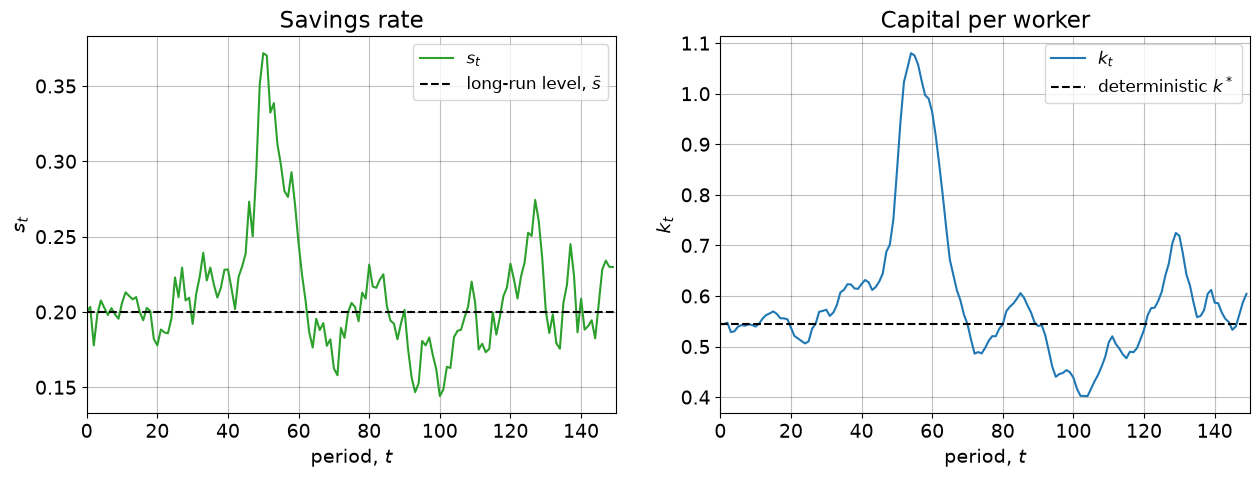

In [31]:
fig = plt.figure(figsize=(13,5))

# a. the savings rate
ax = fig.add_subplot(1,2,1)
ax.plot(sim_stoch.s,lw=1.5,color=colors[2],label='$s_t$')
ax.axhline(model.s,ls='--',lw=1.5,color='black',label=r'long-run level, $\bar{s}$')
ax.set_title('Savings rate')
ax.set_ylabel('$s_t$')

# b. capital
ax = fig.add_subplot(1,2,2)
ax.plot(sim_stoch.k,lw=1.5,color=colors[0],label='$k_t$')
ax.axhline(k_ss,ls='--',lw=1.5,color='black',label='deterministic $k^*$')
ax.set_title('Capital per worker')
ax.set_ylabel('$k_t$')

for ax in fig.axes:
    ax.set_xlabel('period, $t$')
    ax.set_xlim(0,T)
    ax.legend(loc='upper right',fontsize=12)

fig.tight_layout()

Note how different the two panels look. The savings rate jumps up and down from period to period, while capital moves in **long, smooth waves**: capital is a *stock* that is built up slowly, so a single bad period only makes a small dent in it. Only the long-lasting movements in $s_t$ get through.

### 8.2. <a id='toc8_2_'></a>[Many economies](#toc0_)

One simulated path is just *one* possible history. To say something about the **distribution** of outcomes we simulate many economies ("worlds"), each with its own draws - exactly as in lecture 6.

Note that we **copy** the result into `k_all` in each iteration: every call to `simulate` overwrites `model_mc.sim`.

In [32]:
# a. settings
N = 1_000 # number of economies
T = 150 # number of periods

# b. allocate memory
k_all = np.empty((N,T))

# c. simulate: same model, new savings path for each economy
rng = np.random.default_rng(2026)
model_mc = SolowModel(k0=k_ss,T=T)

for i in range(N):
    s_path = draw_savings_rates(rng,T,s_bar=model.s)
    sim = model_mc.simulate(s=s_path)
    k_all[i,:] = sim.k # copy the result out before the next call overwrites it

# d. percentiles across economies in each period
k_median = np.percentile(k_all,50,axis=0)
k_low = np.percentile(k_all,10,axis=0)
k_high = np.percentile(k_all,90,axis=0)

print(f'in the last period: mean = {k_all[:,-1].mean():.3f}, std = {k_all[:,-1].std():.3f}')
print(f'deterministic steady state: k* = {k_ss:.3f}')

in the last period: mean = 0.558, std = 0.114
deterministic steady state: k* = 0.544


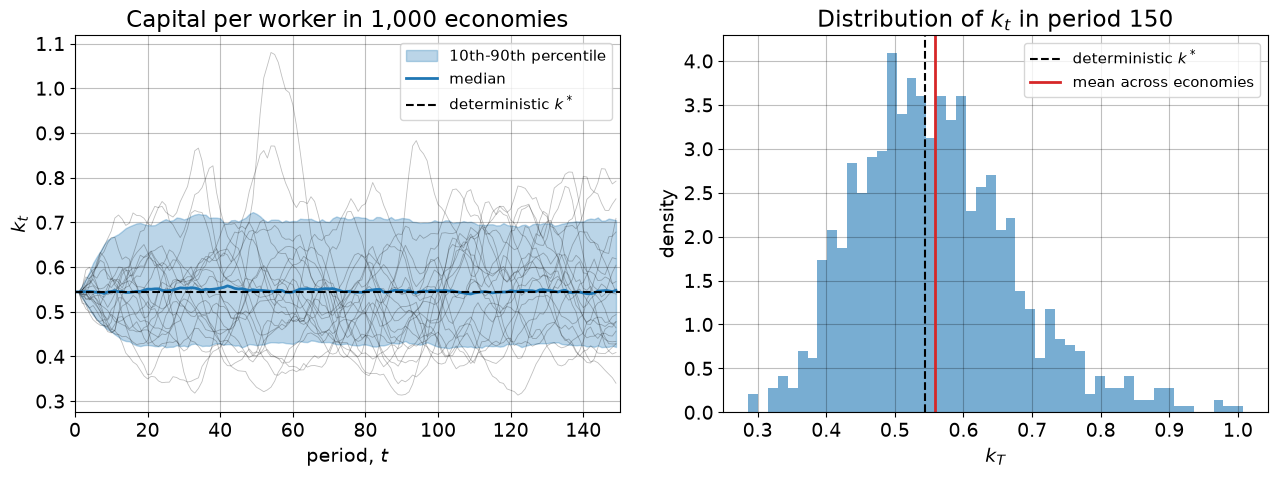

In [33]:
fig = plt.figure(figsize=(13,5))

# a. paths over time
ax = fig.add_subplot(1,2,1)
ax.plot(k_all[:20,:].T,lw=0.6,color='black',alpha=0.25) # 20 individual economies
ax.fill_between(np.arange(T),k_low,k_high,color=colors[0],alpha=0.30,label='10th-90th percentile')
ax.plot(k_median,lw=2,color=colors[0],label='median')
ax.axhline(k_ss,ls='--',lw=1.5,color='black',label='deterministic $k^*$')

ax.set_title(f'Capital per worker in {N:,} economies')
ax.set_xlabel('period, $t$')
ax.set_ylabel('$k_t$')
ax.set_xlim(0,T)
ax.legend(loc='upper right',fontsize=11)

# b. distribution in the last period
ax = fig.add_subplot(1,2,2)
ax.hist(k_all[:,-1],bins=50,density=True,color=colors[0],alpha=0.60)
ax.axvline(k_ss,ls='--',lw=1.5,color='black',label='deterministic $k^*$')
ax.axvline(k_all[:,-1].mean(),lw=2,color=colors[3],label='mean across economies')

ax.set_title(f'Distribution of $k_t$ in period {T}')
ax.set_xlabel('$k_T$')
ax.set_ylabel('density')
ax.legend(loc='upper right',fontsize=11)

fig.tight_layout()

**Two things to notice:**

1. Instead of a single number we now have a whole **distribution** of possible outcomes. That is the pay-off of simulation - and it costs us nothing but a loop over economies, because the model was already written as a reusable class.
2. The distribution is **skewed** and its mean is *not* the deterministic steady state. The model is non-linear, and simulating a non-linear model with average shocks is not the same as taking the average of many simulations. Whenever you add uncertainty to a model, this is worth checking.

### 8.3. <a id='toc8_3_'></a>[Vectorizing over economies (extra)](#toc0_)

The loop above ran the 1,000 economies **one after the other**. But they are completely **independent** - each one only depends on its own shocks - so there is no reason to do them one at a time.

* the loop over **time** cannot be avoided: $k_{t+1}$ needs $k_t$
* the loop over **economies** can: one line of numpy can move all 1,000 economies one period forward

This is the same trick as in lecture 6. We rewrite both the draws and the simulation with the economies stacked in the **rows** of a matrix.

In [34]:
def draw_savings_rates_many(rng,N,T,s_bar,rho=0.90,sigma=0.07):
    """ draw N AR(1) paths for the savings rate at the same time

    Args:

        rng (Generator): random number generator
        N (int): number of economies
        T (int): number of periods
        s_bar (float): long-run average savings rate
        rho (float): persistence of the shocks
        sigma (float): standard deviation of the shocks

    Returns:

        (ndarray): savings rates with shape (N,T)

    """

    # a. all the shocks for all the economies at once
    eps = rng.normal(0,sigma,size=(N,T))

    # b. the AR(1) recursion, one period at a time for all economies
    log_s = np.empty((N,T))
    log_s[:,0] = np.log(s_bar)
    for t in range(1,T):
        log_s[:,t] = (1-rho)*np.log(s_bar) + rho*log_s[:,t-1] + eps[:,t]

    return np.exp(log_s)

def simulate_many(model,s_all,k0):
    """ simulate all the economies in s_all at the same time

    Args:

        model (SolowModel): supplies the parameters
        s_all (ndarray): savings rates with shape (N,T)
        k0 (float): initial capital per worker

    Returns:

        (ndarray): capital per worker with shape (N,T)

    """

    N,T = s_all.shape

    k = np.empty((N,T))
    k[:,0] = k0
    for t in range(T-1): # this one line advances all N economies
        k[:,t+1] = s_all[:,t]*model.f(k[:,t]) + (1-model.delta)*k[:,t]

    return k

Now we can time the two versions against each other. With the **same seed** they draw exactly the same shocks, so they must also give exactly the same result - which is a good test of the new code.

In [35]:
import time

# a. one economy at a time (as in section 8.2)
t0 = time.time()

rng = np.random.default_rng(2026)
k_loop = np.empty((N,T))
for i in range(N):
    s_path = draw_savings_rates(rng,T,s_bar=model.s)
    k_loop[i,:] = model_mc.simulate(s=s_path).k

t_loop = time.time()-t0

# b. all economies at once
t0 = time.time()

rng = np.random.default_rng(2026)
s_all = draw_savings_rates_many(rng,N,T,s_bar=model.s)
k_vec = simulate_many(model,s_all,k0=k_ss)

t_vec = time.time()-t0

# c. compare
print(f'one at a time : {t_loop*1000:8.1f} ms')
print(f'all at once   : {t_vec*1000:8.1f} ms')
print(f'speed-up      : {t_loop/t_vec:8.1f}x')
print(f'exactly the same numbers: {np.allclose(k_loop,k_vec)}')

one at a time :    196.4 ms
all at once   :      7.9 ms
speed-up      :     25.0x
exactly the same numbers: True


**Why bother?** Because it is what makes it realistic to run 100,000 economies instead of 1,000, or to re-run the whole experiment for many parameter values. The rule of thumb: loop over what is *sequential* (time), vectorize what is *independent* (economies).

**Task:** What happens if the shocks do **not** last, $\rho = 0$? Use the fast code to compare the distribution of $k_T$ for $\rho = 0$, $0.5$ and $0.9$ in one figure.

In [36]:
# write your code here

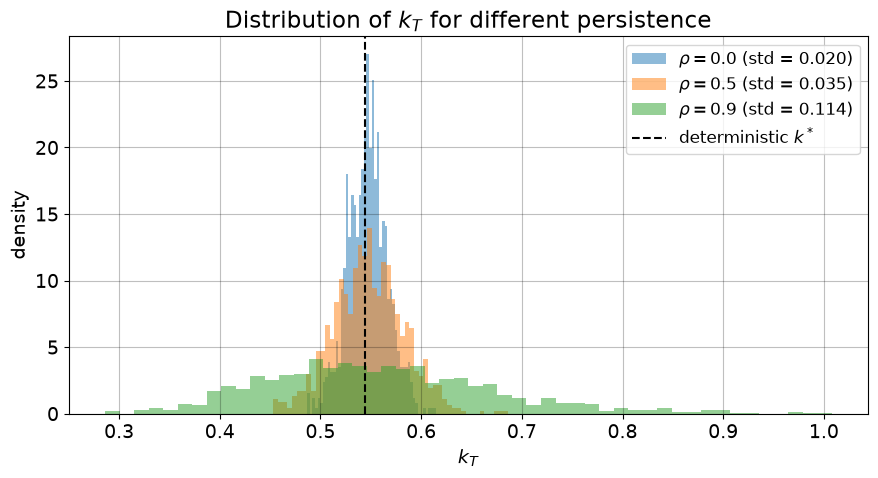

In [37]:
# answer
fig = plt.figure(figsize=(9,5))
ax = fig.add_subplot(1,1,1)

for rho in [0.0,0.5,0.9]:

    rng = np.random.default_rng(2026) # the same shocks in all three cases
    s_all = draw_savings_rates_many(rng,N,T,s_bar=model.s,rho=rho)
    k_rho = simulate_many(model,s_all,k0=k_ss)

    ax.hist(k_rho[:,-1],bins=50,density=True,alpha=0.50,
            label=fr'$\rho={rho:.1f}$ (std = {k_rho[:,-1].std():.3f})')

ax.axvline(k_ss,ls='--',lw=1.5,color='black',label='deterministic $k^*$')

ax.set_title(f'Distribution of $k_T$ for different persistence')
ax.set_xlabel('$k_T$')
ax.set_ylabel('density')
ax.legend(loc='upper right',fontsize=12)

fig.tight_layout()

With $\rho = 0$ the good and bad periods cancel out almost completely: capital barely moves away from $k^{\ast}$. **Persistence makes the economies drift apart.**

## 9. <a id='toc9_'></a>[Summary](#toc0_)

Questions? **Socrative room:** PROGECON

**The programming take-aways:**

1. **Models fit naturally in a class.** Parameters and settings are attributes, the equations and the simulator are methods, and the results are collected in `self.sim`. Several economies can then live side by side.
2. **Flexible inputs.** Letting `simulate` accept either a number or an array for the savings rate made the *same* method work for the baseline, for a permanent policy change and for random shocks.
3. **Analytical and numerical solutions.** Solve by hand when you can, solve with `optimize.root_scalar` or `optimize.minimize_scalar` when you cannot - and use the first to test the second.
4. **Test your code.** A few `assert` statements on cases you already know (the steady state is a resting point, $s=0$ gives pure decay, the accounting adds up) cost two minutes and save hours.
5. **Loops for dynamics.** A recursion like $k_{t+1}=g(k_t)$ has to be a loop over time, but everything else - the grids, the percentiles, the shocks, and the 1,000 independent economies - is vectorized numpy.
6. **Figures.** Always `fig` and `ax`, always a grid, labels, a title and a legend. Use subplots when things are meant to be compared, `fill_between` for regions and `annotate` when a point deserves a name.
7. **Random numbers turn one path into a distribution.** Draw with a seeded generator, simulate many economies, and summarize with percentiles and histograms rather than with a single number.

**And what the model taught us on the way:** an economy converges to a steady state where investment just covers depreciation; it converges fast at first and then ever more slowly; more saving means more capital but not necessarily more consumption; and persistent shocks are what make otherwise identical economies drift apart.